<a href="https://colab.research.google.com/github/pavlenkosasha/MillionaireAPI/blob/main/Uber_Pickups_in_New_York_City_PAVLENKO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

*Что мы подключили
pandas — работа с таблицами и CSV;
numpy — работа с числами и массивами;
matplotlib — построение графиков;*текст курсивом*
seaborn — удобная визуализация данных поверх Matplotlib.*

**Загружаем CSV**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


**Завантажуємо дані за перший тиждень але тшльки 1000 пошздок,(для навчального проеку)**

переглядаємо файли в архіві

In [7]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    print(zip_ref.namelist())

['Uber-Jan-Feb-FOIL.csv', 'other-American_B01362.csv', 'other-Carmel_B00256.csv', 'other-Dial7_B00887.csv', 'other-Diplo_B01196.csv', 'other-FHV-services_jan-aug-2015.csv', 'other-Federal_02216.csv', 'other-Firstclass_B01536.csv', 'other-Highclass_B01717.csv', 'other-Lyft_B02510.csv', 'other-Prestige_B01338.csv', 'other-Skyline_B00111.csv', 'uber-raw-data-apr14.csv', 'uber-raw-data-aug14.csv', 'uber-raw-data-janjune-15.csv', 'uber-raw-data-jul14.csv', 'uber-raw-data-jun14.csv', 'uber-raw-data-may14.csv', 'uber-raw-data-sep14.csv']


вибираємо 1000 поїздок за перший тиждень

In [8]:
import zipfile
import pandas as pd

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    with zip_ref.open("uber-raw-data-apr14.csv") as file:
        all_data = pd.read_csv(file)

all_data["Date/Time"] = pd.to_datetime(all_data["Date/Time"])

week_data = all_data[
    (all_data["Date/Time"] >= "2014-04-01") &
    (all_data["Date/Time"] < "2014-04-08")
]

df = week_data.sample(n=1000, random_state=42)

print("Кількість поїздок:", len(df))
print("Період:", df["Date/Time"].min(), "-", df["Date/Time"].max())

Кількість поїздок: 1000
Період: 2014-04-01 00:07:00 - 2014-04-07 23:23:00


переглядаємо дані




In [9]:
df.head()

,Date/Time,Lat,Lon,Base
44529,2014-04-03 07:55:00,40.7469,-73.9817,B02598
68563,2014-04-07 17:00:00,40.7732,-73.9539,B02598
228250,2014-04-03 18:06:00,40.7559,-73.9768,B02617
373592,2014-04-06 15:04:00,40.7418,-73.9980,B02682
47358,2014-04-03 18:53:00,40.7207,-73.9996,B02598


інформація про таблицю

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 44529 to 59298
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date/Time  1000 non-null   datetime64[ns]
 1   Lat        1000 non-null   float64       
 2   Lon        1000 non-null   float64       
 3   Base       1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 39.1+ KB


статистика
df.describe()

Це покаже статистику числових колонок:

count — кількість;
mean — середнє;
std — стандартне відхилення;
min — мінімум;
25% — перший квартиль;
50% — медіана;
75% — третій квартиль;
max — максимум.

In [13]:
df.describe()

,Date/Time,Lat,Lon
count,1000,1000.00000,1000.000000
mean,2014-04-04 17:20:25.500000,40.74274,-73.978098
min,2014-04-01 00:07:00,40.49360,-74.443700
25%,2014-04-03 07:05:15,40.72475,-73.996425
50%,2014-04-04 18:25:00,40.74445,-73.983400
75%,2014-04-06 00:10:45,40.76290,-73.969075
max,2014-04-07 23:23:00,40.89420,-73.593300
std,NaN,0.03373,0.044822


пропущені значення

In [14]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0


кількість дублікатів

In [15]:
df.duplicated().sum()

np.int64(0)

показуємо дублікати

In [16]:
df[df.duplicated()]

,Date/Time,Lat,Lon,Base


кількість унікальних значень

In [17]:
df.nunique()

,0
Date/Time,924
Lat,642
Lon,567
Base,5


які саме значення Base

In [18]:
df["Base"].unique()

array(['B02598', 'B02617', 'B02682', 'B02512', 'B02764'], dtype=object)

створюємо годину

In [19]:
df["Hour"] = df["Date/Time"].dt.hour

створюємо день місяця

In [20]:
df["Day"] = df["Date/Time"].dt.day

створюємо день тижня

In [21]:
df["DayOfWeek"] = df["Date/Time"].dt.day_name()

перевіряємо результат

In [22]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,DayOfWeek
44529,2014-04-03 07:55:00,40.7469,-73.9817,B02598,7,3,Thursday
68563,2014-04-07 17:00:00,40.7732,-73.9539,B02598,17,7,Monday
228250,2014-04-03 18:06:00,40.7559,-73.9768,B02617,18,3,Thursday
373592,2014-04-06 15:04:00,40.7418,-73.9980,B02682,15,6,Sunday
47358,2014-04-03 18:53:00,40.7207,-73.9996,B02598,18,3,Thursday


перевіряємо розподіл за днями тижня

In [23]:
df["DayOfWeek"].value_counts()

,count
DayOfWeek,
Friday,200
Saturday,168
Monday,149
Thursday,148
Wednesday,115
Tuesday,114
Sunday,106


графік за годинами

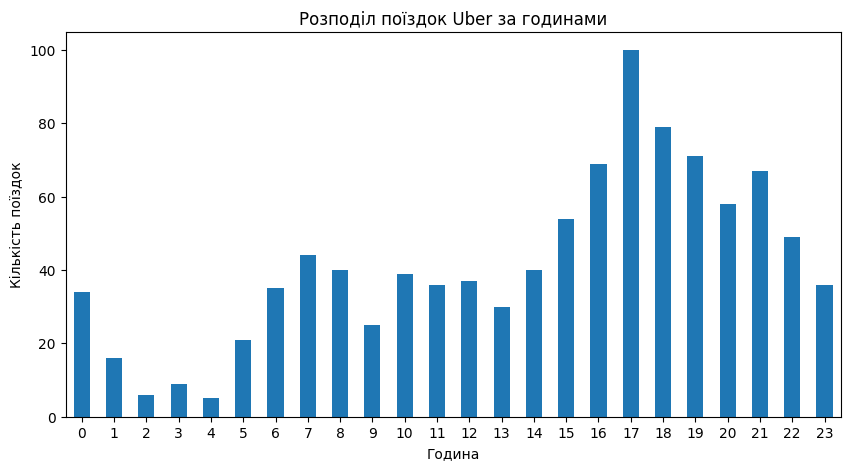

In [24]:
df["Hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Розподіл поїздок Uber за годинами")
plt.xlabel("Година")
plt.ylabel("Кількість поїздок")
plt.xticks(rotation=0)
plt.show()

графік за днями тижня

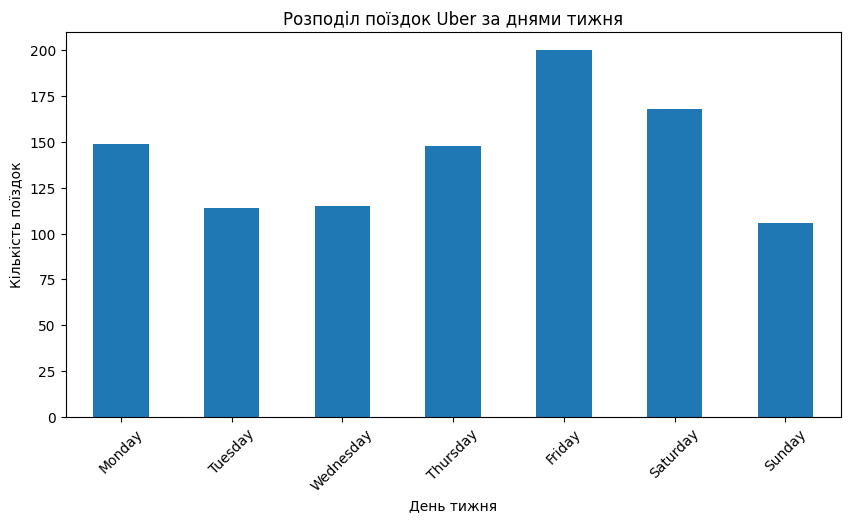

In [25]:
df["DayOfWeek"].value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Розподіл поїздок Uber за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Кількість поїздок")
plt.xticks(rotation=45)
plt.show()

**виконано:

✅ Завантаження даних

✅ Вибір 1000 поїздок

✅ Вибірка за цілий тиждень

✅ Перевірка структури

✅ Статистика

✅ Перевірка пропусків

✅ Перевірка дублікатів

✅ Перевірка унікальних значень

✅ Створення Hour

✅ Створення Day

✅ Створення DayOfWeek

✅ Аналіз за годинами

✅ Аналіз за днями тижня**

дальше 🔵 Кореляція — визначимо, які параметри пов'язані між собою.

In [26]:
correlation = df[["Lat", "Lon", "Hour", "Day"]].corr()

correlation

,Lat,Lon,Hour,Day
Lat,1.000000,0.215744,-0.024720,0.002776
Lon,0.215744,1.000000,-0.049897,-0.043228
Hour,-0.024720,-0.049897,1.000000,0.032900
Day,0.002776,-0.043228,0.032900,1.000000


То есть между самими признаками сильных линейных связей нет.

In [27]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,DayOfWeek
44529,2014-04-03 07:55:00,40.7469,-73.9817,B02598,7,3,Thursday
68563,2014-04-07 17:00:00,40.7732,-73.9539,B02598,17,7,Monday
228250,2014-04-03 18:06:00,40.7559,-73.9768,B02617,18,3,Thursday
373592,2014-04-06 15:04:00,40.7418,-73.9980,B02682,15,6,Sunday
47358,2014-04-03 18:53:00,40.7207,-73.9996,B02598,18,3,Thursday


Цель проекта: предсказать спрос на такси на основе времени, дня недели и других доступных данных.
Что будет Target?

Мы создадим:

NumberOfTrips — количество поездок за определённый час.

1. Считаем количество поездок

In [41]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

df['Date'] = df['Date/Time'].dt.date

target_df = (
    df.groupby(['Date', 'Hour','Day', 'DayOfWeek'])
      .size()
      .reset_index(name='NumberOfTrips')
)

target_df.head()

,Date,Hour,Day,DayOfWeek,NumberOfTrips
0,2014-04-01,0,1,Tuesday,2
1,2014-04-01,1,1,Tuesday,2
2,2014-04-01,2,1,Tuesday,1
3,2014-04-01,4,1,Tuesday,1
4,2014-04-01,5,1,Tuesday,1


In [31]:
target_df['NumberOfTrips'].describe()

,NumberOfTrips
count,153.000000
mean,6.535948
std,4.451532
min,1.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,24.000000


найдём час с самым большим спросом

In [32]:
target_df.loc[target_df['NumberOfTrips'].idxmax()]

,83
Date,2014-04-04
Hour,17
DayOfWeek,Friday
NumberOfTrips,24


посмотрим средний спрос по часам

In [33]:
hour_demand = (
    target_df.groupby('Hour')['NumberOfTrips']
    .mean()
    .reset_index()
)

hour_demand

,Hour,NumberOfTrips
0,0,5.666667
1,1,2.666667
2,2,2.000000
3,3,2.250000
4,4,1.000000
5,5,3.500000
6,6,5.000000
7,7,7.333333
8,8,5.714286
9,9,4.166667


построим первый график 📈

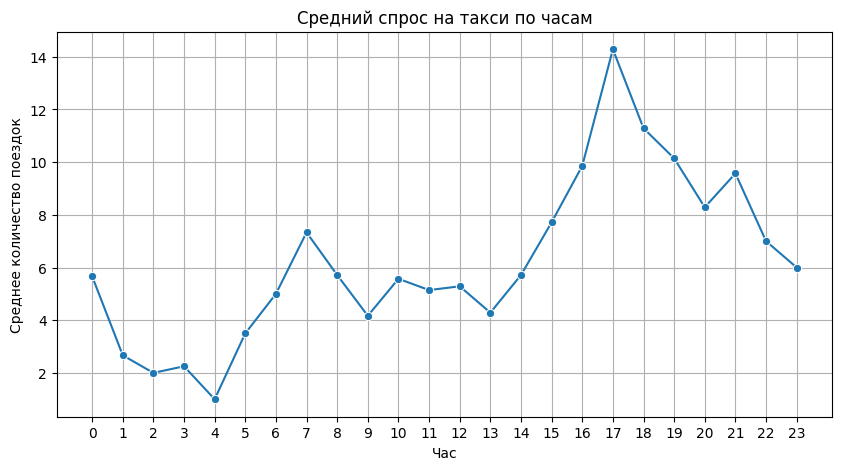

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_demand,
    x='Hour',
    y='NumberOfTrips',
    marker='o'
)

plt.title('Средний спрос на такси по часам')
plt.xlabel('Час')
plt.ylabel('Среднее количество поездок')
plt.xticks(range(24))
plt.grid()
plt.show()

In [35]:
target_df['NumberOfTrips'].describe()

,NumberOfTrips
count,153.000000
mean,6.535948
std,4.451532
min,1.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,24.000000


	NumberOfTrips
count	153.000000
mean	6.535948
std	4.451532
min	1.000000
25%	3.000000
50%	6.000000
75%	9.000000
max	24.000000

dtype: float64

In [36]:
hour_demand = (
    target_df.groupby('Hour')['NumberOfTrips']
    .mean()
    .reset_index()
)

hour_demand

,Hour,NumberOfTrips
0,0,5.666667
1,1,2.666667
2,2,2.000000
3,3,2.250000
4,4,1.000000
5,5,3.500000
6,6,5.000000
7,7,7.333333
8,8,5.714286
9,9,4.166667


In [37]:
hour_demand.sort_values('NumberOfTrips', ascending=False)

,Hour,NumberOfTrips
17,17,14.285714
18,18,11.285714
19,19,10.142857
16,16,9.857143
21,21,9.571429
20,20,8.285714
15,15,7.714286
7,7,7.333333
22,22,7.000000
23,23,6.000000


🧠 Какой вывод?

В нашей неделе данных наблюдается такая закономерность:

Спрос на такси значительно увеличивается во второй половине дня и достигает максимума примерно в 17:00.

«Зверніть увагу, які саме дані впливають на результати (проведіть кореляцію)»

In [39]:
target_df[['Hour', 'NumberOfTrips']].corr()

,Hour,NumberOfTrips
Hour,1.000000,0.464838
NumberOfTrips,0.464838,1.000000


Между Hour и NumberOfTrips наблюдается умеренная положительная линейная связь.

In [42]:
target_df[['Day', 'NumberOfTrips']].corr()

,Day,NumberOfTrips
Day,1.000000,0.133496
NumberOfTrips,0.133496,1.000000


средний спрос по дням недели:

In [43]:
day_demand = (
    target_df.groupby('DayOfWeek')['NumberOfTrips']
    .mean()
    .sort_values(ascending=False)
)

day_demand

,NumberOfTrips
DayOfWeek,
Friday,8.695652
Monday,7.450000
Saturday,7.304348
Thursday,6.434783
Wednesday,5.476190
Sunday,5.300000
Tuesday,4.956522


Теперь сделаем визуализацию 📊

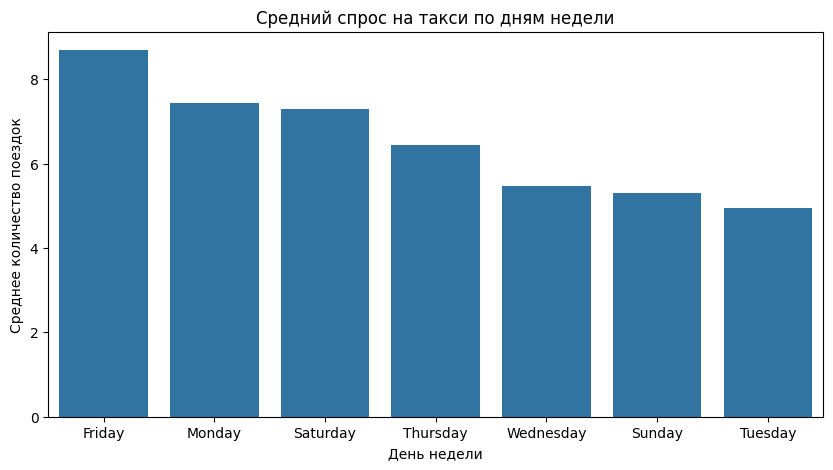

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_demand.index,
    y=day_demand.values
)

plt.title('Средний спрос на такси по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее количество поездок')

plt.show()

hour_demand. Покажем спрос по часам:

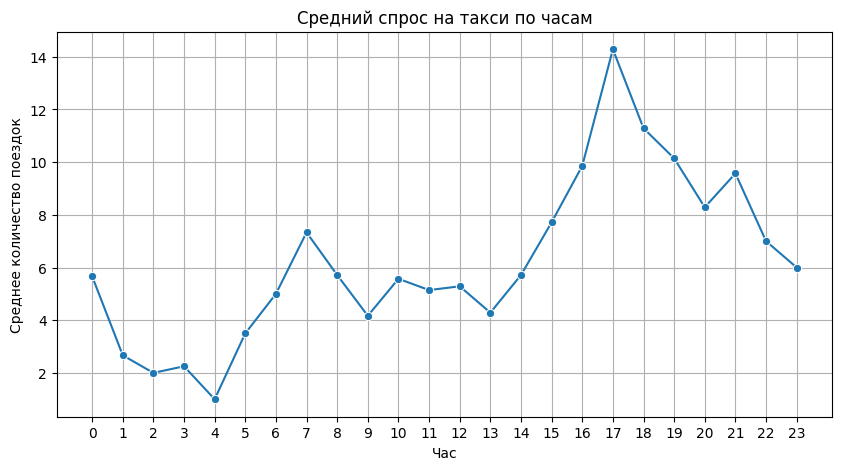

In [45]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_demand,
    x='Hour',
    y='NumberOfTrips',
    marker='o'
)

plt.title('Средний спрос на такси по часам')
plt.xlabel('Час')
plt.ylabel('Среднее количество поездок')

plt.xticks(range(24))
plt.grid()

plt.show()

дальше будет
Да 👍 Делаем тепловую карту: день недели × час. Она нам очень пригодится, потому что покажет, в какие часы и в какие дни спрос выше.